In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

In [3]:
import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

In [4]:
import experiment_utils
from main import *

In [5]:
import main
argd = main.Args()

argd.n_iters = 50000
argd.log_every = 1000

args_all = []
gol_p = 133519  # 6152, 133519, 7291, 7803, 34335, 34591, 14782, 33823, 55615, 2579, 55871
for seed in range(5):
    for dt in [1, 2, 4, 8, 16, 32, 64]:
        args = copy.deepcopy(argd)
        args.seed = seed
        args.data.dt = dt
        args.data.gol_params = gol_p
        args.save_dir = f"data/run_1/dt={dt}_gol={gol_p}_{seed}"
        args_all.append(args)
        print(args)
experiment_utils.create_commands(args_all, prefix="python main.py", out_file="science_scripts/main_2.sh");

Args(seed=0, save_dir='data/run_1/dt=1_gol=133519_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=133519, grid_size=64, t_start=32, t_end=64, dt=1))
Args(seed=0, save_dir='data/run_1/dt=2_gol=133519_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=133519, grid_size=64, t_start=32, t_end=64, dt=2))
Args(seed=0, save_dir='data/run_1/dt=4_gol=133519_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=133519, grid_size=64, t_start=32, t_end=64, dt=4))
Args(seed=0, save_dir='data/run_1/

In [6]:
import linear_probe2
argd = linear_probe2.LinearProbeArgs()

argd.n_iters = 10000
argd.log_every = 1000
argd.opt.weight_decay = 0.

lp_args_all = []
for args in args_all:
    for target in ['x0', 'x1']:
        lp_args = copy.deepcopy(argd)
        lp_args.seed = args.seed
        lp_args.target = target
        lp_args.load_dir = args.save_dir
        lp_args.save_dir = f"{args.save_dir}_lp_{target}"
        lp_args_all.append(lp_args)
        print(lp_args)

args = args_all[0]
for seed in range(5):
    for target in ['x0', 'x1']:
        lp_args = copy.deepcopy(argd)
        lp_args.seed = seed
        lp_args.target = target
        lp_args.load_dir = args.save_dir
        lp_args.save_dir = f"{args.save_dir}_lp_{target}_zero"
        lp_args.zero_features = True
        lp_args_all.append(lp_args)
        print(lp_args)

experiment_utils.create_commands(lp_args_all, prefix="python linear_probe2.py", out_file="science_scripts/linear_probe_2.sh");

LinearProbeArgs(seed=0, load_dir='data/run_1/dt=1_gol=133519_0', save_dir='data/run_1/dt=1_gol=133519_0_lp_x0', n_iters=10000, log_every=1000, target='x0', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_1/dt=1_gol=133519_0', save_dir='data/run_1/dt=1_gol=133519_0_lp_x1', n_iters=10000, log_every=1000, target='x1', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_1/dt=2_gol=133519_0', save_dir='data/run_1/dt=2_gol=133519_0_lp_x0', n_iters=10000, log_every=1000, target='x0', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_1/dt=2_gol=133519_0', save_dir='data/run_1/dt=2_gol=133519_0_lp_x1', n_iters=10000, log_every=1000, target='x1', opt=OptimizerArgs(batch_size=32

```bash
python linear_probe.py --seed=0 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/zero_features_0_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=True
python linear_probe.py --seed=1 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/zero_features_1_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=True
python linear_probe.py --seed=2 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/zero_features_2_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=True
python linear_probe.py --seed=3 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/zero_features_3_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=True
python linear_probe.py --seed=4 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/zero_features_4_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=True



python linear_probe2.py --seed=0 --load_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0"  --save_dir="/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0_lp"  --n_iters=10000 --log_every=1000 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=0.0 --opt.clip_grad_norm=1.0 --zero_features=False
```

In [7]:
df_x0 = []
for args, lp_args in zip(args_all, lp_args_all[:-10:2]):
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss = np.mean(loss_history[-5000:])
    metrics = util.load_pkl(lp_args.save_dir, "metrics")
    score, mse, cossim = metrics['score'], metrics['mse'], metrics['cossim']
    dfi = dict(loss=loss, score=score, mse=mse, cossim=cossim, seed=args.seed, dt=args.data.dt, zero_features=lp_args.zero_features, target_x0=(lp_args.target=='x0'))
    df_x0.append(dfi)
df_x0 = pd.DataFrame(df_x0)

df2 = []
args = args_all[0]
for lp_args in lp_args_all[-10:][::2]:
    metrics = util.load_pkl(lp_args.save_dir, "metrics")
    score, mse, cossim = metrics['score'], metrics['mse'], metrics['cossim']
    dfi = dict(score=score, mse=mse, cossim=cossim, seed=args.seed, dt=args.data.dt)
    df2.append(dfi)
df2 = pd.DataFrame(df2)
a = df2.groupby('dt').mean()

baseline_data_x0 = dict(score=a.score.item(), mse=a.mse.item(), cossim=a.cossim.item())
baseline_data_x0

{'score': -0.0003176792524755001,
 'mse': 5.5952077673282474e-05,
 'cossim': 0.9855721473693848}

In [8]:
df_x0

,loss,score,mse,cossim,seed,dt,zero_features,target_x0
0,7.552591e-11,0.138418,0.000047,0.9878781,0,1,False,True
1,9.851984e-12,0.137659,0.000047,0.98787224,0,2,False,True
2,2.070888e-07,0.132659,0.000047,0.98780394,0,4,False,True
3,1.823499e-03,0.127954,0.000048,0.987747,0,8,False,True
4,4.853226e-01,0.135375,0.000047,0.9878637,0,16,False,True
5,5.972753e-01,0.142618,0.000047,0.98796314,0,32,False,True
6,6.426704e-01,0.148905,0.000046,0.98806286,0,64,False,True
7,2.043540e-07,0.142043,0.000047,0.98776656,1,1,False,True
8,1.195986e-08,0.137463,0.000048,0.9876985,1,2,False,True
9,7.999288e-06,0.132862,0.000048,0.98763794,1,4,False,True


In [9]:
df_x1 = []
for args, lp_args in zip(args_all, lp_args_all[1:-10:2]):
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss = np.mean(loss_history[-5000:])
    metrics = util.load_pkl(lp_args.save_dir, "metrics")
    score, mse, cossim = metrics['score'], metrics['mse'], metrics['cossim']
    dfi = dict(loss=loss, score=score, mse=mse, cossim=cossim, seed=args.seed, dt=args.data.dt, zero_features=lp_args.zero_features, target_x0=(lp_args.target=='x0'))
    df_x1.append(dfi)
df_x1 = pd.DataFrame(df_x1)

df2 = []
args = args_all[0]
for lp_args in lp_args_all[-10:][1::2]:
    metrics = util.load_pkl(lp_args.save_dir, "metrics")
    score, mse, cossim = metrics['score'], metrics['mse'], metrics['cossim']
    dfi = dict(score=score, mse=mse, cossim=cossim, seed=args.seed, dt=args.data.dt)
    df2.append(dfi)
df2 = pd.DataFrame(df2)
a = df2.groupby('dt').mean()

baseline_data_x1 = dict(score=a.score.item(), mse=a.mse.item(), cossim=a.cossim.item())
baseline_data_x1

{'score': -0.0003733675694093108,
 'mse': 5.5567674280609936e-05,
 'cossim': 0.9856720924377441}

In [10]:
df_x1

,loss,score,mse,cossim,seed,dt,zero_features,target_x0
0,7.552591e-11,0.145297,0.000047,0.98792064,0,1,False,False
1,9.851984e-12,0.131833,0.000049,0.98746353,0,2,False,False
2,2.070888e-07,0.124427,0.000049,0.9872947,0,4,False,False
3,1.823499e-03,0.130785,0.000050,0.9871337,0,8,False,False
4,4.853226e-01,0.113286,0.000052,0.98665786,0,16,False,False
5,5.972753e-01,0.097733,0.000055,0.9859456,0,32,False,False
6,6.426704e-01,0.077739,0.000061,0.98421246,0,64,False,False
7,2.043540e-07,0.146160,0.000047,0.9878649,1,1,False,False
8,1.195986e-08,0.135643,0.000047,0.98799276,1,2,False,False
9,7.999288e-06,0.126274,0.000048,0.9877333,1,4,False,False


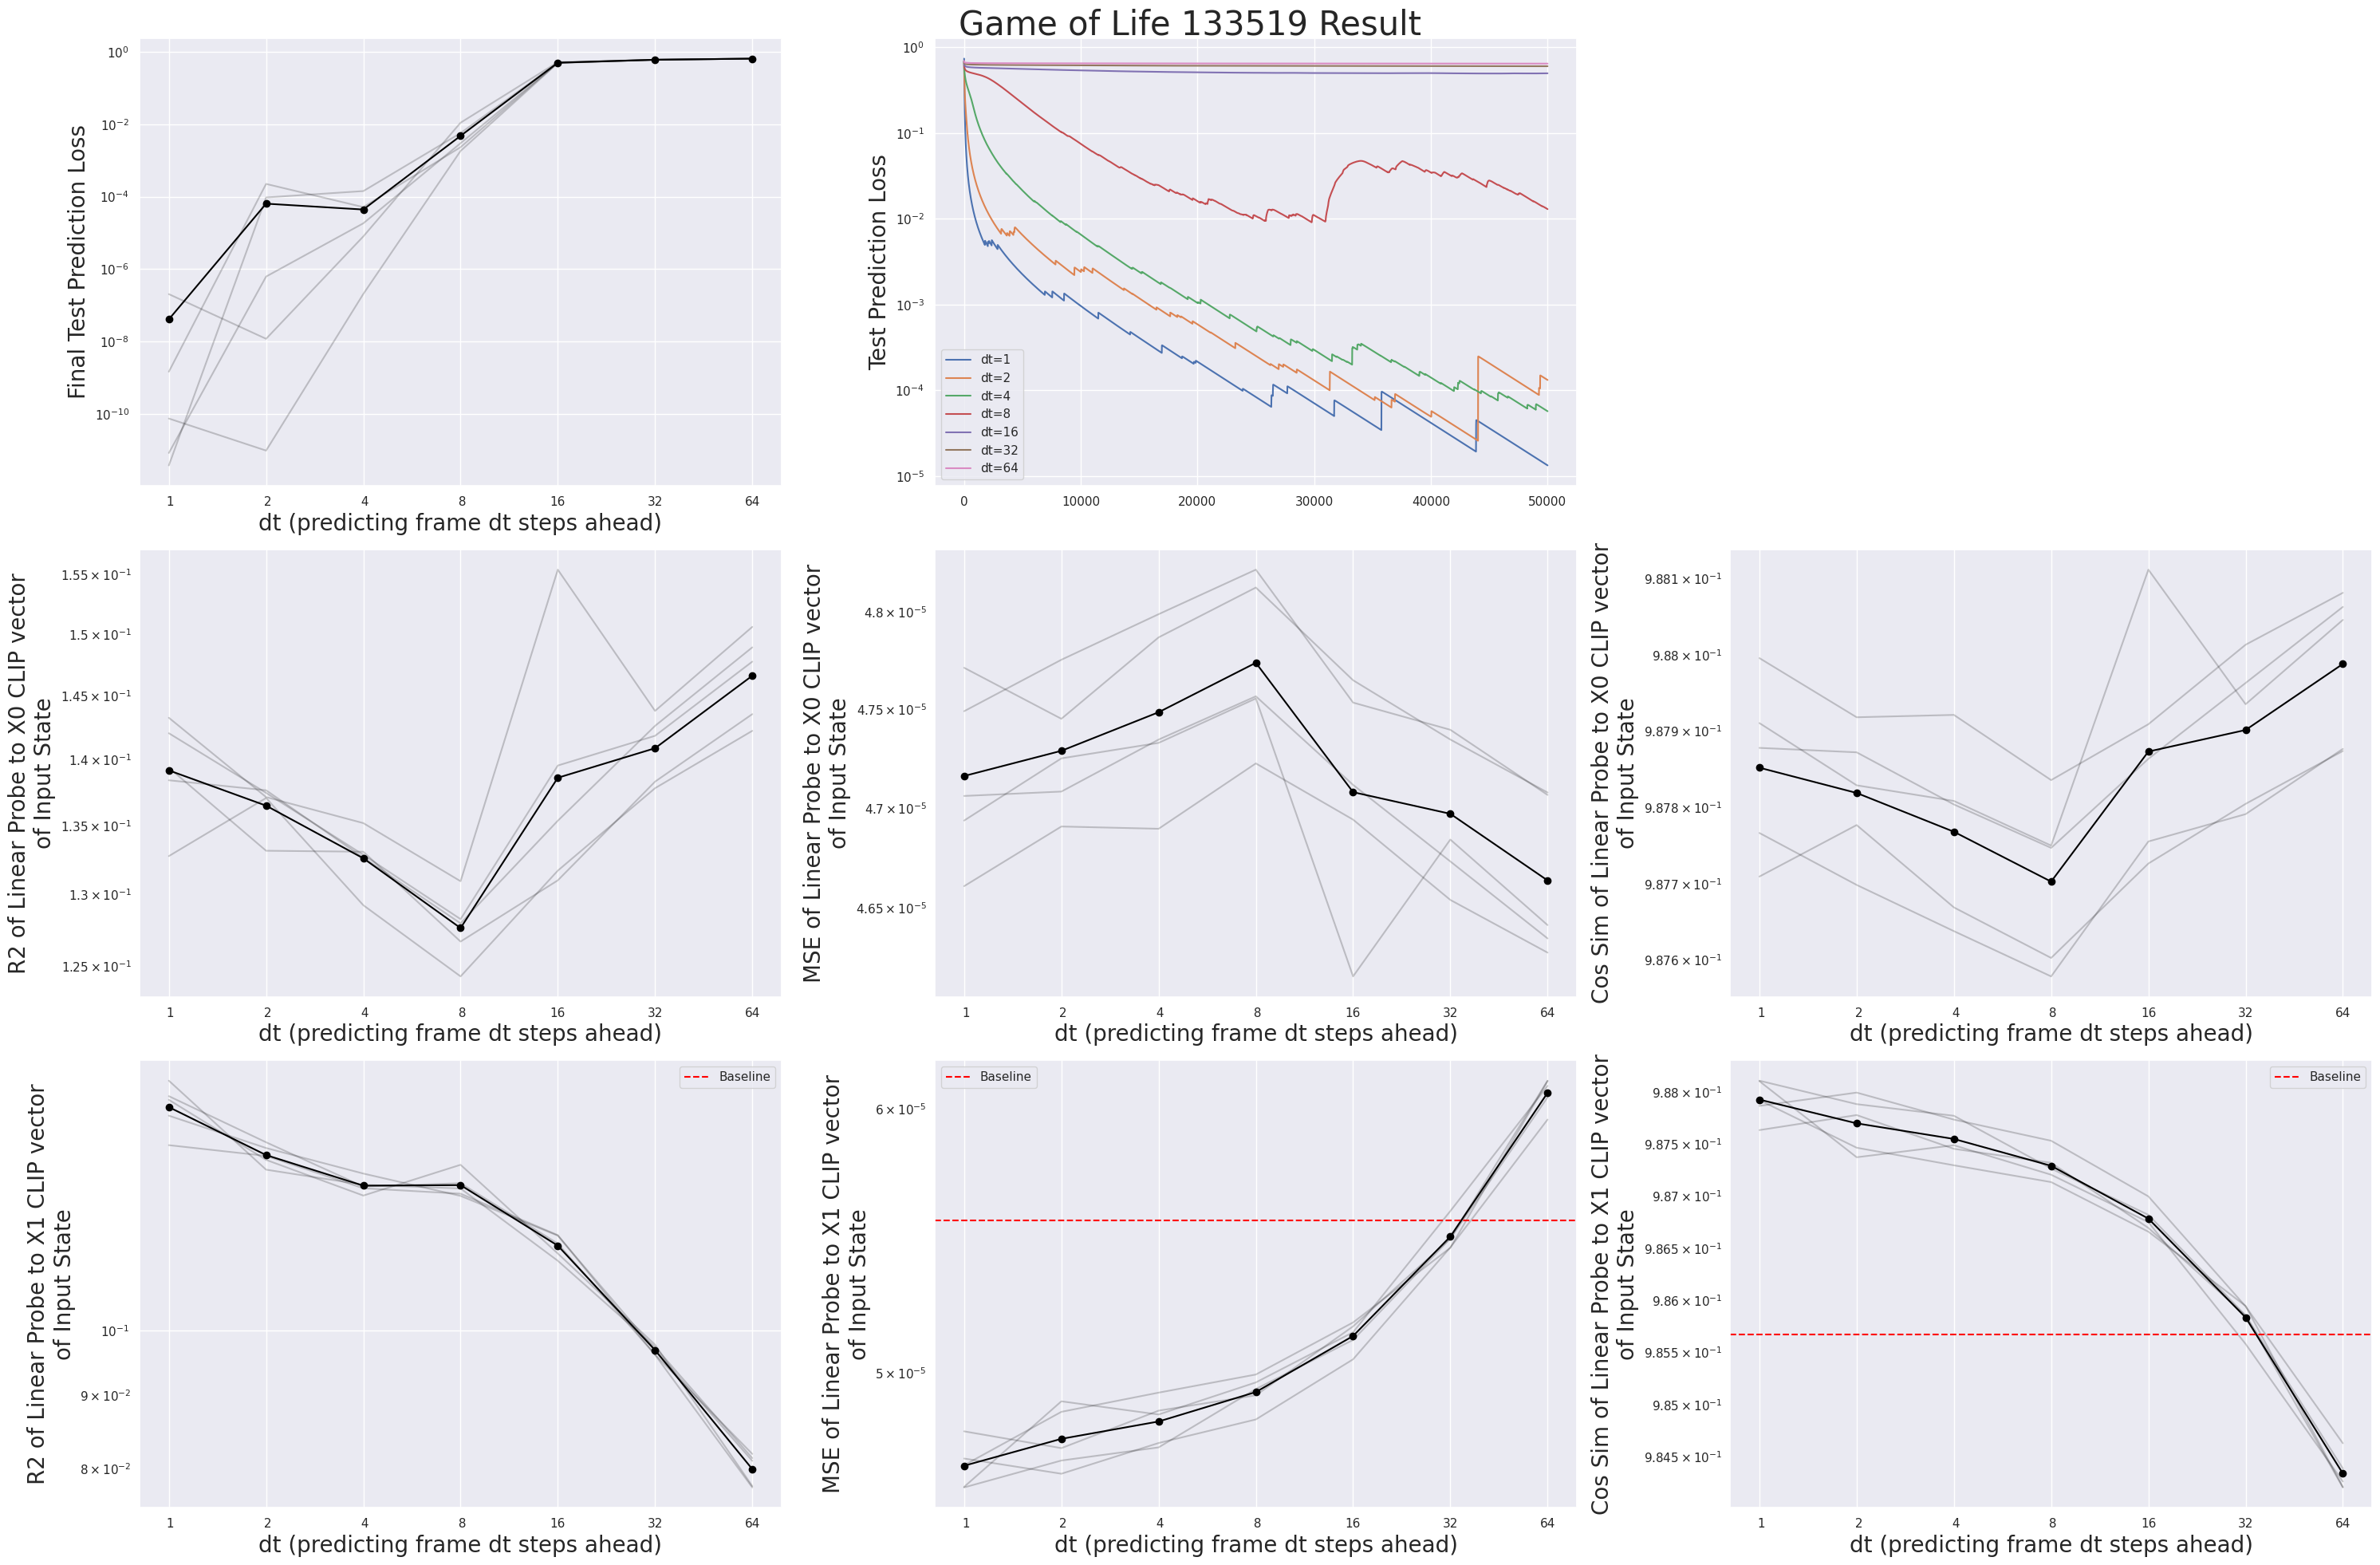

In [12]:
fig = plt.figure(figsize=(30, 20))

plt.subplot(3, 3, 1)
for seed in range(5):
    a = df_x0[df_x0.seed==seed]
    plt.plot(a.dt, a.loss, c='black', alpha=0.2)
a = df_x0.groupby("dt").mean()
plt.plot(a.index, a.loss, c='black', alpha=1)
plt.scatter(a.index, a.loss, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Final Test Prediction Loss", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
# plt.axhline(y=np.log(2), c='red', ls='--', label='Random Prediction')
# plt.legend()

plt.subplot(3, 3, 2)
for dt in df_x0.dt.unique():
    loss_data = []
    for args in args_all:
        if args.data.dt != dt:
            continue
        loss_data.append(np.array(util.load_pkl(args.save_dir, "loss_history")))
    loss_data = np.array(loss_data)
    mean, std = loss_data.mean(axis=0), loss_data.std(axis=0)
    mean = pd.DataFrame(mean).ewm(span=10000).mean()
    plt.plot(mean, label=f'dt={dt}')
plt.yscale('log')
plt.legend()
plt.ylabel('Test Prediction Loss', fontsize=20)
# plt.xlabel('SGD Training Iterations', fontsize=20)
# plt.axhline(y=np.log(2), c='red', ls='--')

plt.subplot(3, 3, 4)
for seed in range(5):
    a = df_x0[df_x0.seed==seed]
    plt.plot(a.dt, a.score, c='black', alpha=0.2)
a = df_x0.groupby("dt").mean()
plt.plot(a.index, a.score, c='black', alpha=1)
plt.scatter(a.index, a.score, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("R2 of Linear Probe to X0 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
# plt.axhline(y=baseline_data_x0['score'], c='red', ls='--', label='Baseline')
# plt.legend()

plt.subplot(3, 3, 5)
for seed in range(5):
    a = df_x0[df_x0.seed==seed]
    plt.plot(a.dt, a.mse, c='black', alpha=0.2)
a = df_x0.groupby("dt").mean()
plt.plot(a.index, a.mse, c='black', alpha=1)
plt.scatter(a.index, a.mse, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("MSE of Linear Probe to X0 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
# plt.axhline(y=baseline_data_x0['mse'], c='red', ls='--', label='Baseline')
# plt.legend()

plt.subplot(3, 3, 6)
for seed in range(5):
    a = df_x0[df_x0.seed==seed]
    plt.plot(a.dt, a.cossim, c='black', alpha=0.2)
a = df_x0.groupby("dt").mean()
plt.plot(a.index, a.cossim, c='black', alpha=1)
plt.scatter(a.index, a.cossim, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Cos Sim of Linear Probe to X0 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
# plt.axhline(y=baseline_data_x0['cossim'], c='red', ls='--', label='Baseline')
# plt.legend()

plt.subplot(3, 3, 7)
for seed in range(5):
    a = df_x1[df_x1.seed==seed]
    plt.plot(a.dt, a.score, c='black', alpha=0.2)
a = df_x1.groupby("dt").mean()
plt.plot(a.index, a.score, c='black', alpha=1)
plt.scatter(a.index, a.score, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("R2 of Linear Probe to X1 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
plt.axhline(y=baseline_data_x1['score'], c='red', ls='--', label='Baseline')
plt.legend()

plt.subplot(3, 3, 8)
for seed in range(5):
    a = df_x1[df_x1.seed==seed]
    plt.plot(a.dt, a.mse, c='black', alpha=0.2)
a = df_x1.groupby("dt").mean()
plt.plot(a.index, a.mse, c='black', alpha=1)
plt.scatter(a.index, a.mse, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("MSE of Linear Probe to X1 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
plt.axhline(y=baseline_data_x1['mse'], c='red', ls='--', label='Baseline')
plt.legend()

plt.subplot(3, 3, 9)
for seed in range(5):
    a = df_x1[df_x1.seed==seed]
    plt.plot(a.dt, a.cossim, c='black', alpha=0.2)
a = df_x1.groupby("dt").mean()
plt.plot(a.index, a.cossim, c='black', alpha=1)
plt.scatter(a.index, a.cossim, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Cos Sim of Linear Probe to X1 CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])
plt.axhline(y=baseline_data_x1['cossim'], c='red', ls='--', label='Baseline')
plt.legend()

fig.suptitle(f'Game of Life {gol_p} Result', fontsize=30)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig(f'figures/{gol_p}_result.png')
plt.show()

## Visualize predictions

In [16]:
df = []
for args, lp_args in zip(args_all[:35], lp_args_all[:35]):
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss = np.mean(loss_history[-5000:])
    metrics = util.load_pkl(lp_args.save_dir, "metrics")
    score, mse, cossim = metrics['score'], metrics['mse'], metrics['cossim']
    dfi = dict(loss=loss, score=score, mse=mse, cossim=cossim, seed=args.seed, dt=args.data.dt, zero_features=lp_args.zero_features, args=args, lp_args=lp_args)
    df.append(dfi)
df = pd.DataFrame(df)

In [22]:
for dt in [1, 2, 4, 8, 16]:
    a = df[df.dt==dt]
    a = a[a.loss == a.loss.min()]
    args = a.args.item()
    save_dir = args.save_dir
    params = util.load_pkl(save_dir, "params")

In [23]:
args = copy.deepcopy(args)
if isinstance(args.data.dt, int):
    args.data.dt = [args.data.dt]
print(args)
dts = jnp.array(args.data.dt)
dt_max = dts.max().item()

net = create_net(args)
substrate = GameOfLife(grid_size=args.data.grid_size)
rollout_fn = partial(rollout_simulation, s0=None, substrate=substrate, fm=None, rollout_steps=args.data.t_end+dt_max,
                        time_sampling='video', img_size=None, return_state=True)

def generate_batch(rng):
    rng, _rng = split(rng)
    state = rollout_fn(_rng, args.data.gol_params)['state']

    rng, _rng = split(rng)
    t0 = jax.random.randint(_rng, shape=(), minval=args.data.t_start, maxval=args.data.t_end)

    rng, _rng = split(rng)
    dt_id = jax.random.randint(_rng, shape=(), minval=0, maxval=len(dts))
    dt = dts[dt_id]
    t1 = t0 + dt
    x0, x1 = state[t0], state[t1]
    return dict(x0=x0, x1=x1, dt_id=dt_id, dt=dt, state=state, t0=t0, t1=t1)

generate_batch_vmap = jax.jit(jax.vmap(generate_batch))

Args(seed=4, save_dir='data/run_2/dt=16_gol=7291_4', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[16]))


In [24]:
rng = jax.random.PRNGKey(0)
batch = generate_batch_vmap(split(rng, 16))
x0, x1, dt_id = batch['x0'], batch['x1'], batch['dt_id']
logits = jax.vmap(net.apply, in_axes=(None, 0, 0))(params, x0, dt_id)
x1_pred = jnp.argmax(logits, axis=-1)

In [25]:
batch['dt']

Array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16],      dtype=int32)

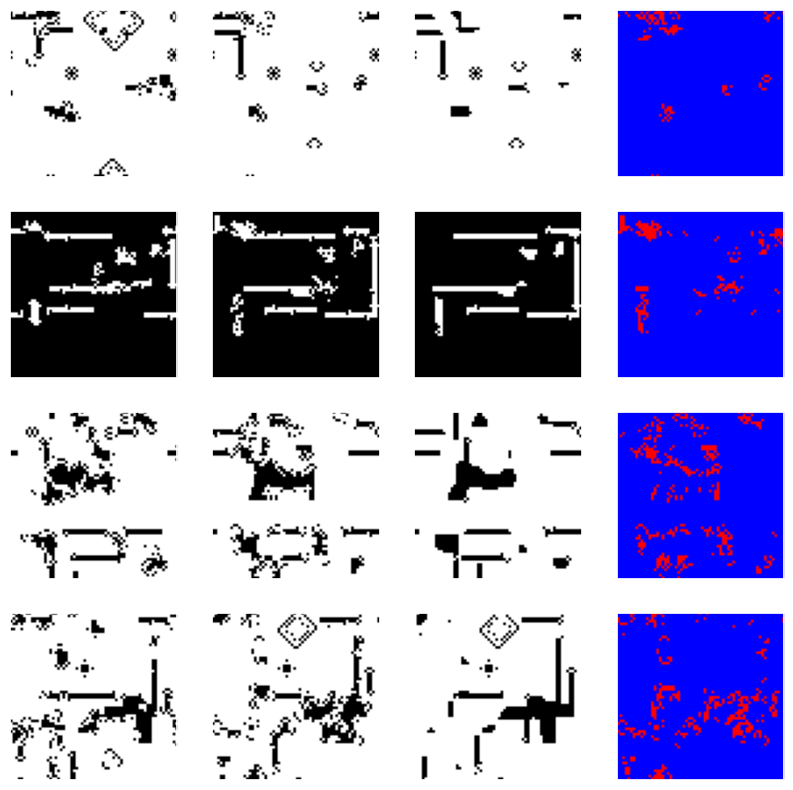

In [26]:
plt.figure(figsize=(10, 10))
iplt = 0
for i in range(4):
    iplt += 1
    plt.subplot(4, 4, iplt); plt.xticks([]); plt.yticks([])
    plt.imshow(x0[i], cmap='gray')
    iplt += 1
    plt.subplot(4, 4, iplt); plt.xticks([]); plt.yticks([])
    plt.imshow(x1[i], cmap='gray')
    iplt += 1
    plt.subplot(4, 4, iplt); plt.xticks([]); plt.yticks([])
    plt.imshow(x1_pred[i], cmap='gray')
    iplt += 1
    plt.subplot(4, 4, iplt); plt.xticks([]); plt.yticks([])
    plt.imshow(x1_pred[i] != x1[i], cmap='bwr')
plt.show()

## Check which layers are more important for linear probe

In [27]:
data = []
for args, lp_args in zip(args_all, lp_args_all):
    if args.data.dt < 8:
        continue
    print(lp_args)
    reg = util.load_pkl(lp_args.save_dir, "reg")
    data.append(np.abs(reg.coef_).mean(axis=0))
data = np.stack(data)

LinearProbeArgs(seed=0, load_dir='data/run_2/dt=2_gol=7291_0', save_dir='data/run_2/dt=2_gol=7291_0_lp_x1', n_iters=10000, log_every=1000, target='x1', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_2/dt=4_gol=7291_0', save_dir='data/run_2/dt=4_gol=7291_0_lp_x0', n_iters=10000, log_every=1000, target='x0', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_2/dt=4_gol=7291_0', save_dir='data/run_2/dt=4_gol=7291_0_lp_x1', n_iters=10000, log_every=1000, target='x1', opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), zero_features=False)
LinearProbeArgs(seed=0, load_dir='data/run_2/dt=8_gol=7291_0', save_dir='data/run_2/dt=8_gol=7291_0_lp_x0', n_iters=10000, log_every=1000, target='x0', opt=OptimizerArgs(batch_size=32, learning_rate=

In [28]:
data.shape

(20, 512)

Text(0, 0.5, 'Influence on Linear Probe')

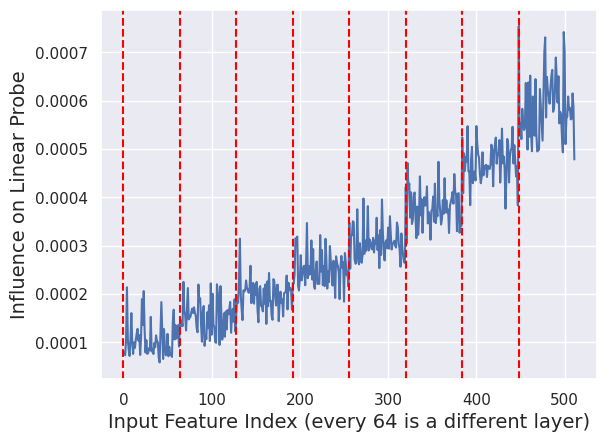

In [29]:
plt.plot(data.mean(axis=0))
for i in range(0, 512, 64):
    plt.axvline(i, color='red', linestyle='--')
plt.xlabel('Input Feature Index (every 64 is a different layer)', fontsize=14)
plt.ylabel("Influence on Linear Probe", fontsize=14)